In [1]:
!pip install timm -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Mounted at /content/drive


In [3]:
BASE_DIR = "/content/drive/MyDrive/BrainTumor_Project"
DATASET_DIR = os.path.join(BASE_DIR, "Dataset")

train_dir = os.path.join(DATASET_DIR, "Training")
test_dir = os.path.join(DATASET_DIR, "Testing")

os.makedirs(os.path.join(BASE_DIR, "Trained_Model"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "Results"), exist_ok=True)

print("Train:", train_dir, os.path.exists(train_dir))
print("Test:", test_dir, os.path.exists(test_dir))

if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise Exception("Dataset path wrong. Your folders must be BrainTumor_Project/Dataset/Training and Testing")

Train: /content/drive/MyDrive/BrainTumor_Project/Dataset/Training True
Test: /content/drive/MyDrive/BrainTumor_Project/Dataset/Testing True


In [4]:
class CLAHETransform:
    def __call__(self, img):
        img = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        lab = cv2.merge((l,a,b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

def tumor_roi_segmentation(image):
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    roi = cv2.bitwise_and(img, img, mask=mask)
    return mask, roi

In [5]:
train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))
print("Classes:", class_names)

Training Images: 5600
Testing Images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
class AttentionFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(dim // 2, dim),
            nn.Sigmoid()
        )

        self.channel_attention = nn.Sequential(
            nn.Linear(dim, dim // 4),
            nn.GELU(),
            nn.Linear(dim // 4, dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.gate(x) * self.channel_attention(x)


class NeuroVisionSegFusionNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.efficientnet = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )

        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        self.convnext = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0
        )

        total_dim = (
            self.efficientnet.num_features +
            self.swin.num_features +
            self.convnext.num_features
        )

        self.fusion = AttentionFusion(total_dim)

        self.classifier = nn.Sequential(
            nn.Linear(total_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        f1 = F.normalize(self.efficientnet(x), dim=1)
        f2 = F.normalize(self.swin(x), dim=1)
        f3 = F.normalize(self.convnext(x), dim=1)

        fused = torch.cat([f1, f2, f3], dim=1)
        fused = self.fusion(fused)

        return self.classifier(fused)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuroVisionSegFusionNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

SAVE_PATH = "/content/drive/MyDrive/BrainTumor_Project/Trained_Model/neurovision_segfusion_model.pth"

print("Model ready on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model ready on: cuda


/tmp/ipykernel_7408/2374842377.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [10]:
epochs = 25
best_val_acc = 0

train_acc_list = []
val_acc_list = []
loss_list = []

for epoch in range(epochs):

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    train_acc = 100 * correct / total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    loss_list.append(total_loss / len(train_loader))

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {total_loss / len(train_loader):.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved")

    print("-" * 50)

print("Best Validation Accuracy:", best_val_acc)

/tmp/ipykernel_7408/1936841414.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25
Loss: 0.6013
Train Accuracy: 88.84%
Validation Accuracy: 89.75%
Best model saved
--------------------------------------------------
Epoch 2/25
Loss: 0.5210
Train Accuracy: 93.02%
Validation Accuracy: 93.56%
Best model saved
--------------------------------------------------
Epoch 3/25
Loss: 0.4765
Train Accuracy: 95.05%
Validation Accuracy: 92.75%
--------------------------------------------------
Epoch 4/25
Loss: 0.4485
Train Accuracy: 95.91%
Validation Accuracy: 94.06%
Best model saved
--------------------------------------------------
Epoch 5/25
Loss: 0.4253
Train Accuracy: 97.18%
Validation Accuracy: 94.06%
--------------------------------------------------
Epoch 6/25
Loss: 0.4224
Train Accuracy: 97.38%
Validation Accuracy: 94.50%
Best model saved
--------------------------------------------------
Epoch 7/25
Loss: 0.4065
Train Accuracy: 97.98%
Validation Accuracy: 94.56%
Best model saved
--------------------------------------------------
Epoch 8/25
Loss: 0.3983
Train Acc

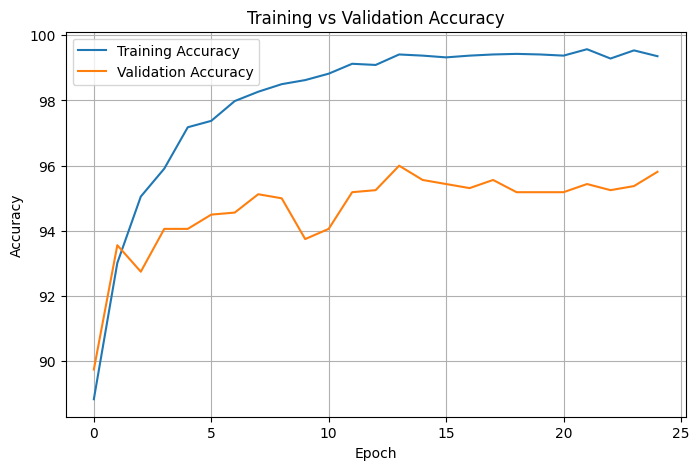

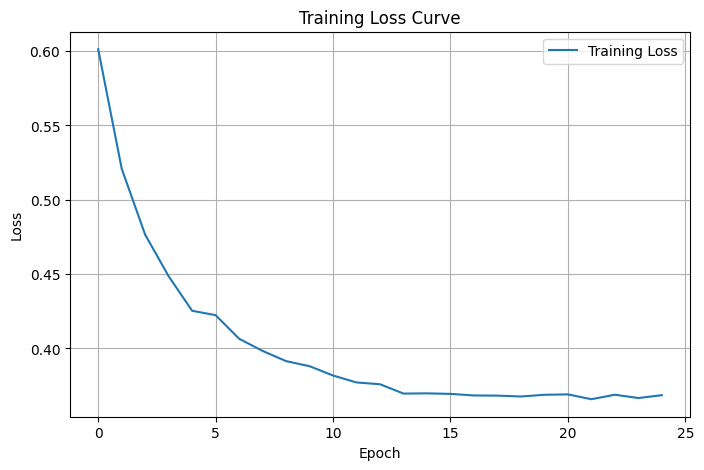

In [11]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_list, label="Training Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss_list, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid()
plt.show()

In [12]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", round(acc * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 96.0 %
Precision: 96.22 %
Recall: 96.0 %
F1 Score: 95.92 %

Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.85      0.92       400
  meningioma       0.93      0.99      0.96       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



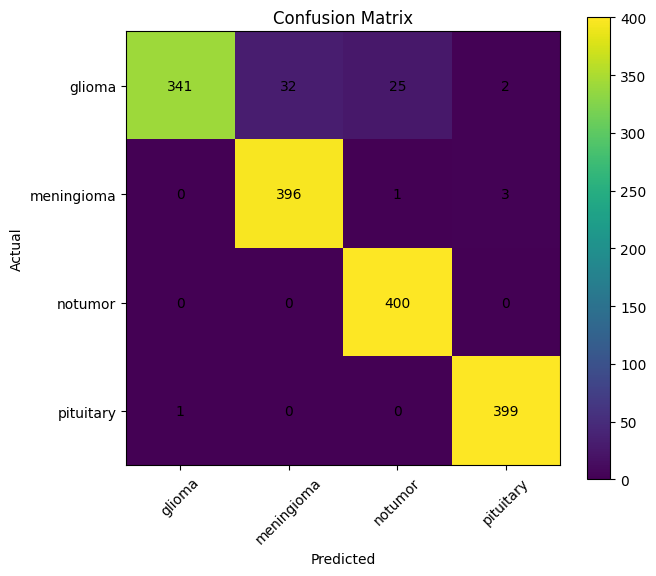

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Saving Te-aug-me_60.jpg to Te-aug-me_60.jpg
Predicted Class: meningioma
Confidence: 84.58 %


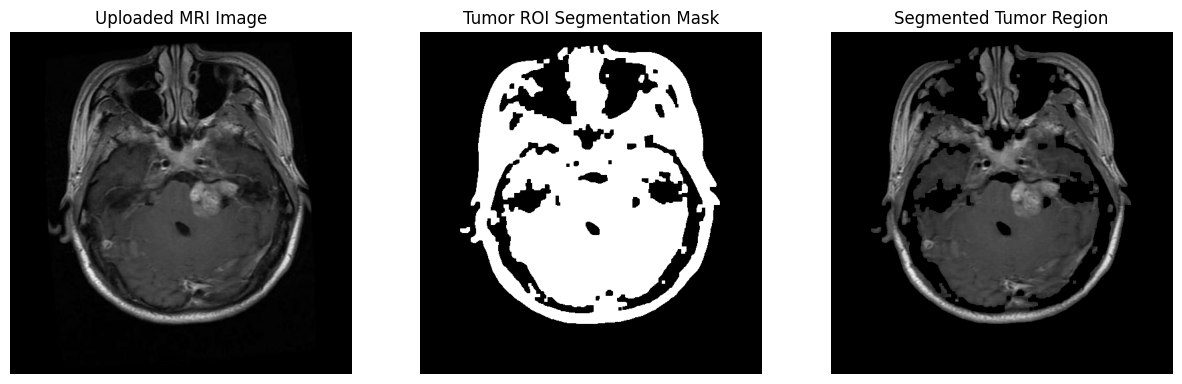

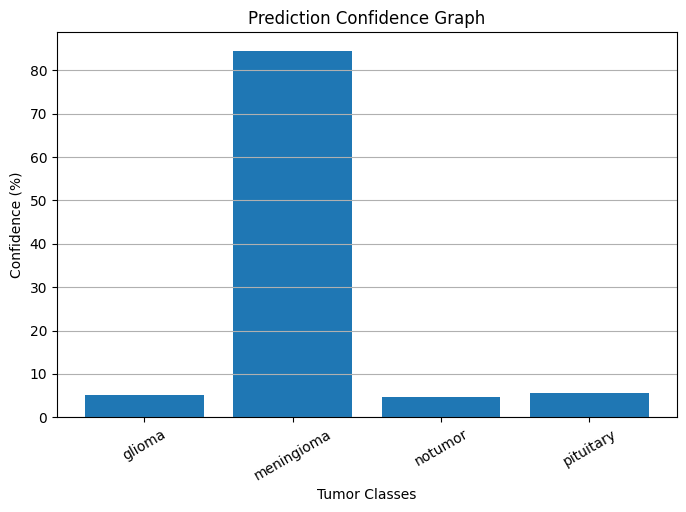

In [14]:
from google.colab import files

def predict_uploaded_image(image_path):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model.eval()

    image = Image.open(image_path).convert("RGB")

    mask, roi = tumor_roi_segmentation(image)

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0]

    pred_idx = torch.argmax(probabilities).item()
    pred_class = class_names[pred_idx]
    confidence = probabilities[pred_idx].item() * 100

    print("Predicted Class:", pred_class)
    print("Confidence:", round(confidence, 2), "%")

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Uploaded MRI Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Tumor ROI Segmentation Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(roi)
    plt.title("Segmented Tumor Region")
    plt.axis("off")

    plt.show()

    plt.figure(figsize=(8,5))
    plt.bar(class_names, probabilities.cpu().numpy() * 100)
    plt.xlabel("Tumor Classes")
    plt.ylabel("Confidence (%)")
    plt.title("Prediction Confidence Graph")
    plt.xticks(rotation=30)
    plt.grid(axis="y")
    plt.show()


uploaded = files.upload()
image_path = list(uploaded.keys())[0]

predict_uploaded_image(image_path)